<a href="https://colab.research.google.com/github/episode16/Py/blob/master/DLS_mipt/game_of_thrones_hw1/hw_1_game_of_thrones_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

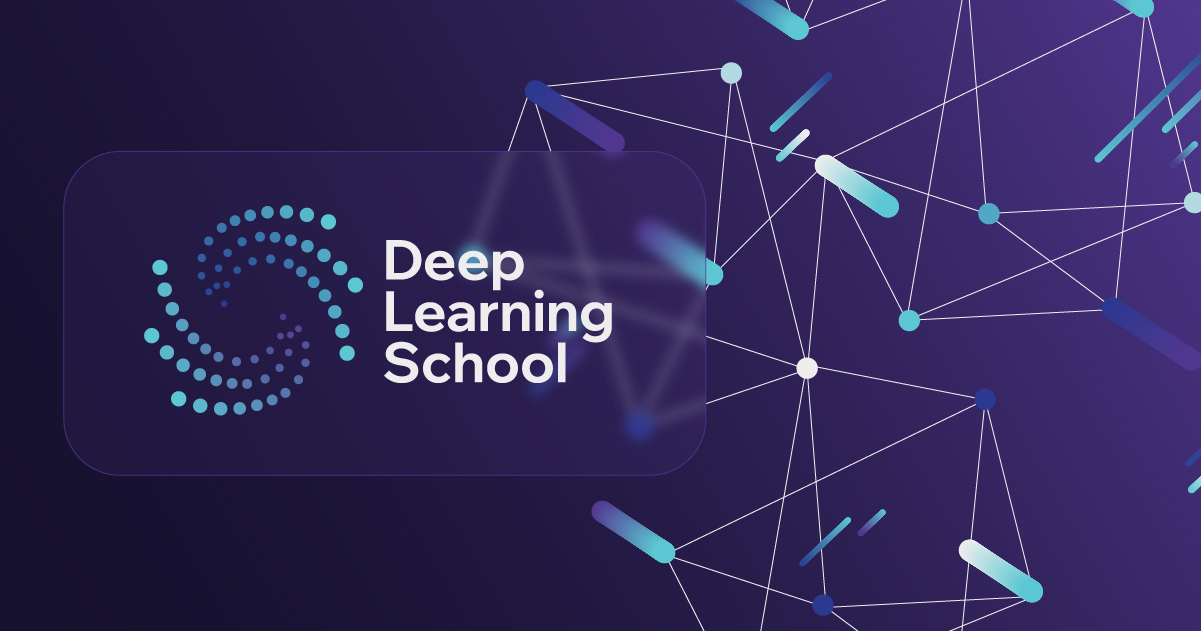

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

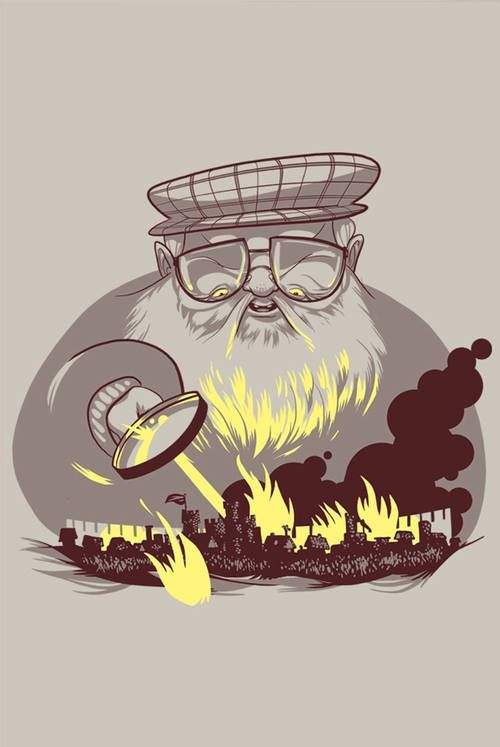

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [2]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 43.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 60.5MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [428]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [474]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [475]:
df = pd.read_csv('/content/game_of_thrones_train.csv', index_col = 'S.No')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                381
spouse              1357
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse       1357
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64


<BarContainer object of 25 artists>

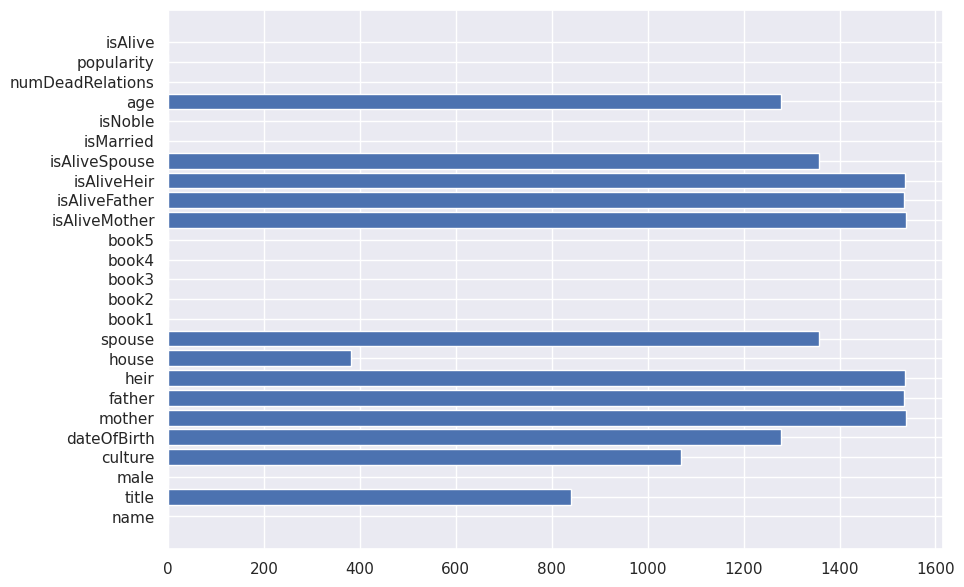

In [476]:
data = df.isna().sum()
print(data)
plt.figure(figsize=(10,7))

plt.barh(data.index, data.values)

<Axes: xlabel='S.No'>

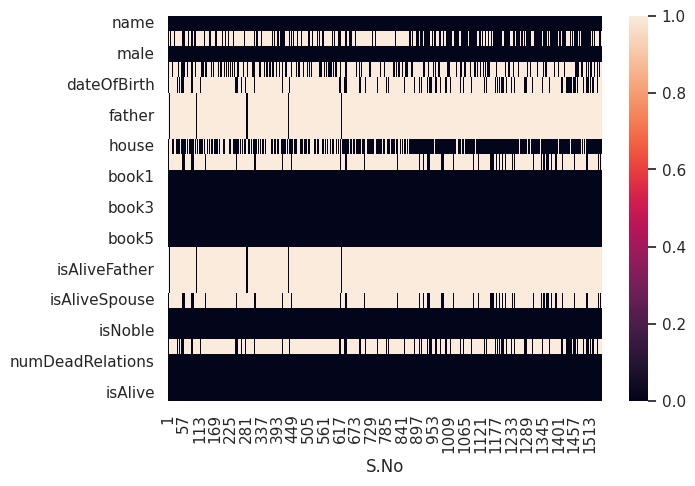

In [477]:
plt.figure(figsize=(7,5))

sns.heatmap(df.isna().transpose())

In [478]:
columns = df.columns
column_del = []
for column in columns:
  na_percentage = round((df[column].isna().sum() / len(df[column])) * 100, 3)
  print(f'{na_percentage} % пропущенных данных у признака {column}')
  if na_percentage > 83: #тк у ['age'] пропусков также много, но пока этот признак оставляем
    column_del.append(column)

column_del

0.0 % пропущенных данных у признака name
53.95 % пропущенных данных у признака title
0.0 % пропущенных данных у признака male
68.658 % пропущенных данных у признака culture
82.081 % пропущенных данных у признака dateOfBirth
98.844 % пропущенных данных у признака mother
98.587 % пропущенных данных у признака father
98.651 % пропущенных данных у признака heir
24.47 % пропущенных данных у признака house
87.155 % пропущенных данных у признака spouse
0.0 % пропущенных данных у признака book1
0.0 % пропущенных данных у признака book2
0.0 % пропущенных данных у признака book3
0.0 % пропущенных данных у признака book4
0.0 % пропущенных данных у признака book5
98.844 % пропущенных данных у признака isAliveMother
98.587 % пропущенных данных у признака isAliveFather
98.651 % пропущенных данных у признака isAliveHeir
87.155 % пропущенных данных у признака isAliveSpouse
0.0 % пропущенных данных у признака isMarried
0.0 % пропущенных данных у признака isNoble
82.081 % пропущенных данных у признака a

['mother',
 'father',
 'heir',
 'spouse',
 'isAliveMother',
 'isAliveFather',
 'isAliveHeir',
 'isAliveSpouse']

### Анализ age

age
100.0    20
19.0     12
15.0     11
16.0     11
20.0     11
         ..
33.0      1
86.0      1
80.0      1
58.0      1
77.0      1
Name: count, Length: 72, dtype: int64
Среднее = 35.29032258064516
Медиана = 24.0


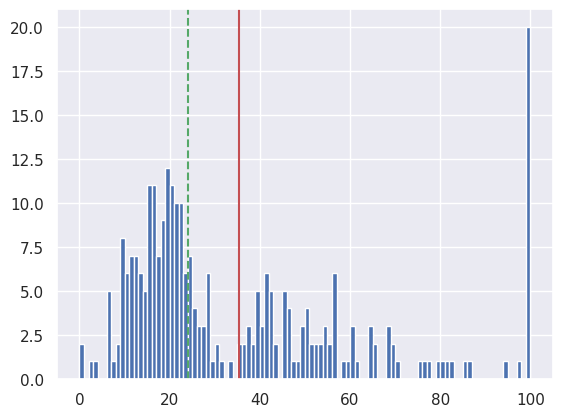

279


In [479]:
# смотрю на медиану и среднюю возраста
print(df['age'].dropna().value_counts())

mean_Age = np.mean(df['age'].dropna().values)
median_Age = np.quantile(df['age'].dropna().values,q=0.5)

print(f"Среднее = {mean_Age}")
print(f"Медиана = {median_Age}")


plt.hist(df['age'], bins = 100)

plt.axvline(x=mean_Age, color='r', linestyle = '-', label='mean')
plt.axvline(x=median_Age, color='g', linestyle = '--', label='median')

plt.show()

print(df['age'].dropna().value_counts().sum())

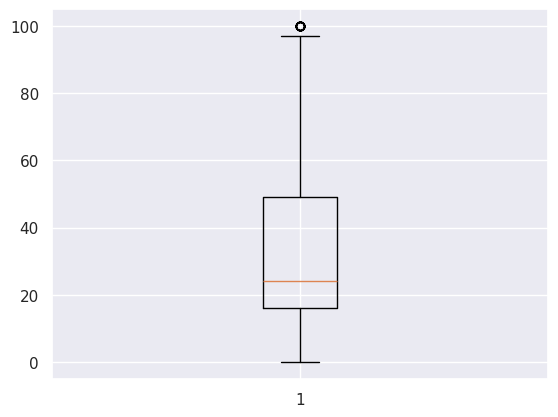

In [480]:
# Построить boxplot для выявления выбросов
plt.boxplot(df['age'].dropna())
plt.show()

Здесь я вижу, что у меня значения 100 - выброс. Отсюда делаю вывод, что пропуски NaN заполняю медианой

Однако если обратить внимание на age и dateOfBirth то можно сразу сказать, что если известны оба эти 2 признака, то можно понять жив или мертв персонаж. Поэтому NaN в age и dateOfBirth заполняю -1

In [481]:
df['age'] = df['age'].fillna(-1)


### Анализ title

In [482]:
df['title'].value_counts()

,count
title,
Ser,306
Maester,29
Archmaester,21
Lord,19
Septon,16
...,...
Lord of Hellholt,1
Red Flower Vale,1
Lord of Harrenhal,1


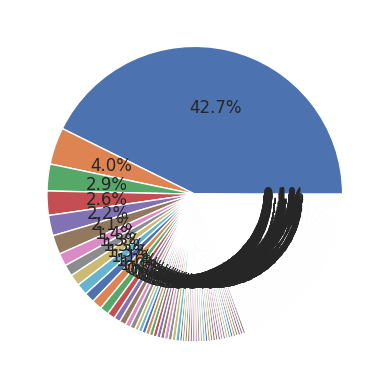

In [483]:
# Готовим данные для круговой диаграммы
data = df['title'].value_counts()

plt.pie(data, autopct='%1.1f%%')

plt.show()

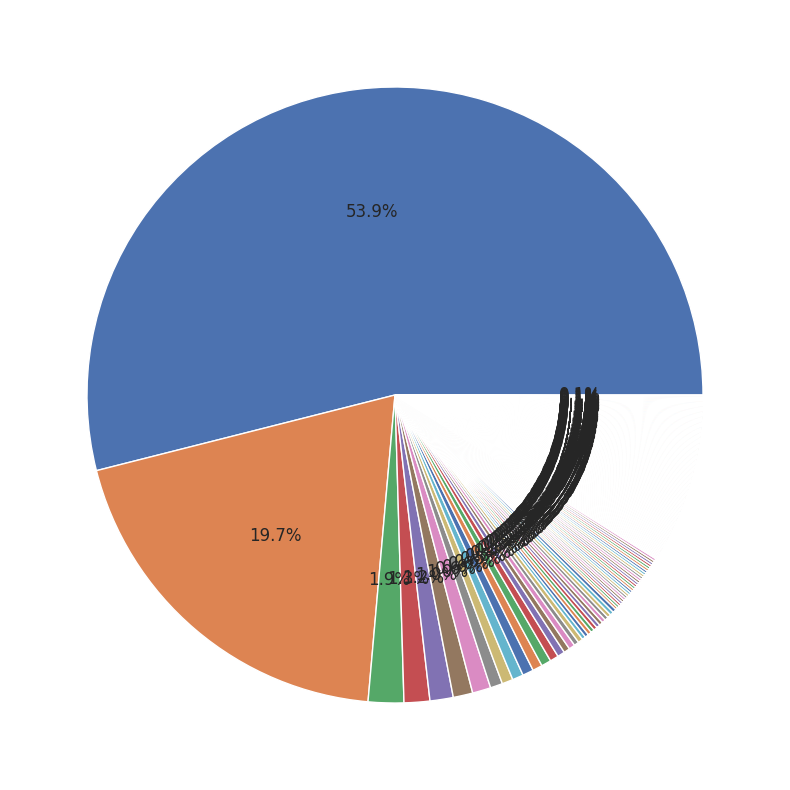

In [484]:
df.loc[df['title'].isna(), 'title'] = 'other'

data = df['title'].value_counts()
plt.figure(figsize=(20, 10))
plt.pie(data, autopct='%1.1f%%')
plt.show()

In [485]:
dict_title = dict(df['title'].value_counts())
print(dict_title)


{'other': np.int64(840), 'Ser': np.int64(306), 'Maester': np.int64(29), 'Archmaester': np.int64(21), 'Lord': np.int64(19), 'Septon': np.int64(16), 'Winterfell': np.int64(15), 'Lady': np.int64(10), 'King in the North': np.int64(9), 'Septa': np.int64(9), 'Princess': np.int64(9), 'Cupbearer': np.int64(8), "Lord Commander of the Night's Watch": np.int64(8), 'Prince': np.int64(7), 'Grand Maester': np.int64(6), 'Khal': np.int64(5), 'Wisdom': np.int64(5), 'Prince of Dragonstone': np.int64(4), 'King-Beyond-the-Wall': np.int64(4), 'Queen': np.int64(3), 'Last Hearth': np.int64(3), 'Casterly Rock': np.int64(3), 'Bitterbridge': np.int64(3), 'Lord Paramount of the Mander': np.int64(3), 'Eyrie': np.int64(3), 'Lord of the Tides': np.int64(3), 'Bloodrider': np.int64(3), 'Brother': np.int64(3), 'Duskendale': np.int64(3), 'Starpike': np.int64(3), 'Harrenhal': np.int64(3), 'King': np.int64(2), 'Good Master': np.int64(2), 'Hornwood': np.int64(2), 'Ashford': np.int64(2), 'Hand of the King': np.int64(2), 'S

{'other': np.int64(840), 'Ser': np.int64(306), 'Maester': np.int64(29), 'Archmaester': np.int64(21), 'Lord': np.int64(19), 'Septon': np.int64(16), 'Winterfell': np.int64(15), 'Lady': np.int64(10), 'King in the North': np.int64(9), 'Septa': np.int64(9), 'Princess': np.int64(9), 'Cupbearer': np.int64(8), "Lord Commander of the Night's Watch": np.int64(8), 'Prince': np.int64(7), 'Grand Maester': np.int64(6), 'Khal': np.int64(5), 'Wisdom': np.int64(5), 'Prince of Dragonstone': np.int64(4), 'King-Beyond-the-Wall': np.int64(4), 'Queen': np.int64(3), 'Last Hearth': np.int64(3), 'Casterly Rock': np.int64(3), 'Bitterbridge': np.int64(3), 'Lord Paramount of the Mander': np.int64(3), 'Eyrie': np.int64(3), 'Lord of the Tides': np.int64(3), 'Bloodrider': np.int64(3), 'Brother': np.int64(3), 'Duskendale': np.int64(3), 'Starpike': np.int64(3), 'Harrenhal': np.int64(3), 'King': np.int64(2), 'Good Master': np.int64(2), 'Hornwood': np.int64(2), 'Ashford': np.int64(2), 'Hand of the King': np.int64(2), 'S

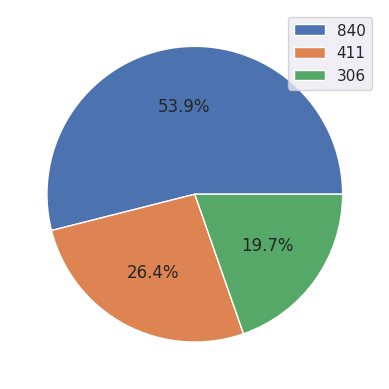

In [486]:
print(dict_title)
rare_title = []
for title in dict_title.items():
  if title[1] < 30:
    rare_title.append(title[0])
rare_title

df['title'] = df['title'].replace(rare_title, 'Rare')
data = df['title'].value_counts()

plt.pie(data, autopct='%1.1f%%')
plt.legend(data)
plt.show()

In [487]:
print(df)
print(df.isna().sum())

                      name  title  male     culture  dateOfBirth  \
S.No                                                               
1     Viserys II Targaryen  other     1         NaN          NaN   
2              Walder Frey   Rare     1    Rivermen        208.0   
3             Addison Hill    Ser     1         NaN          NaN   
4              Aemma Arryn   Rare     0         NaN         82.0   
5           Sylva Santagar   Rare     0     Dornish        276.0   
...                    ...    ...   ...         ...          ...   
1553                Marwyn   Rare     1         NaN          NaN   
1554          Masha Heddle  other     0         NaN          NaN   
1555      Matthos Seaworth  other     1         NaN          NaN   
1556            Meera Reed  other     0  Crannogmen        283.0   
1557    Melara Hetherspoon  other     0         NaN        264.0   

                  mother            father                heir  \
S.No                                             

### Анализ культуры

culture
Northmen                   94
Ironborn                   91
Free Folk                  45
Braavosi                   39
Valyrian                   28
Ghiscari                   17
Dornish                    17
Dothraki                   17
Reach                      13
Vale mountain clans        12
Rivermen                   10
Valemen                    10
northmen                    9
Westerman                   8
Free folk                   7
Tyroshi                     6
Qartheen                    5
Stormlands                  4
Summer Isles                4
Astapori                    4
Westeros                    3
Dornishmen                  3
Ironmen                     3
Northern mountain clans     3
Westermen                   3
Lysene                      2
westermen                   2
Meereenese                  2
Myrish                      2
Crannogmen                  2
Sistermen                   2
First Men                   2
Lhazarene                   1
No

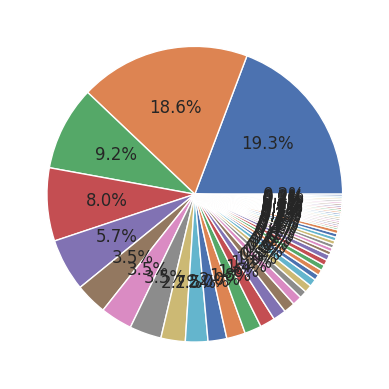

array([nan, 'Rivermen', 'Dornish', 'Valyrian', 'Ironborn', 'Free Folk',
       'Northmen', 'Summer Isles', 'Braavosi', 'Dothraki', 'Ghiscari',
       'Vale mountain clans', 'Reach', 'Tyroshi', 'Lhazarene',
       'Free folk', 'Ironmen', 'Qartheen', 'Lysene', 'westermen',
       'Westerman', 'Qarth', 'Lyseni', 'northmen', 'Qohor', 'Westeros',
       'Norvoshi', 'First Men', 'Meereenese', 'Andal', 'Astapori',
       'Westermen', 'ironborn', 'Ghiscaricari', 'Braavos', 'Stormlands',
       'Valemen', 'Myrish', 'Lhazareen', 'Dornishmen', 'Sistermen',
       'Northern mountain clans', 'Andals', 'Vale', 'Crannogmen',
       'Wildling', 'Dorne', 'Pentoshi', 'free folk', 'Summer Islander',
       'Westerlands', 'Summer Islands'], dtype=object)

In [488]:
# Готовим данные для круговой диаграммы
data = df['culture'].value_counts()
print(data)
plt.pie(data, autopct='%1.1f%%')
plt.show()

#print(data)
#print(df['culture'].isna().sum())

cultures = df['culture'].unique()
cultures

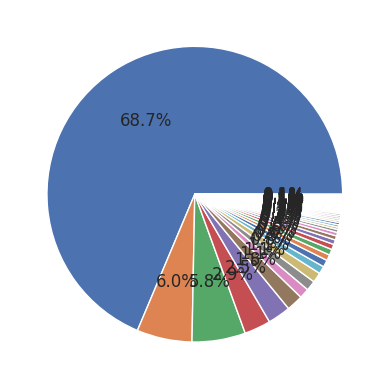

In [489]:
df.loc[df['culture'].isna(), 'culture'] = 'other'

data = df['culture'].value_counts()

plt.pie(data, autopct='%1.1f%%')
plt.show()

In [490]:
dict_culture = dict(df['culture'].value_counts())
print(dict_culture)


{'other': np.int64(1069), 'Northmen': np.int64(94), 'Ironborn': np.int64(91), 'Free Folk': np.int64(45), 'Braavosi': np.int64(39), 'Valyrian': np.int64(28), 'Ghiscari': np.int64(17), 'Dornish': np.int64(17), 'Dothraki': np.int64(17), 'Reach': np.int64(13), 'Vale mountain clans': np.int64(12), 'Rivermen': np.int64(10), 'Valemen': np.int64(10), 'northmen': np.int64(9), 'Westerman': np.int64(8), 'Free folk': np.int64(7), 'Tyroshi': np.int64(6), 'Qartheen': np.int64(5), 'Stormlands': np.int64(4), 'Summer Isles': np.int64(4), 'Astapori': np.int64(4), 'Westeros': np.int64(3), 'Dornishmen': np.int64(3), 'Ironmen': np.int64(3), 'Northern mountain clans': np.int64(3), 'Westermen': np.int64(3), 'Lysene': np.int64(2), 'westermen': np.int64(2), 'Meereenese': np.int64(2), 'Myrish': np.int64(2), 'Crannogmen': np.int64(2), 'Sistermen': np.int64(2), 'First Men': np.int64(2), 'Lhazarene': np.int64(1), 'Norvoshi': np.int64(1), 'Qohor': np.int64(1), 'Braavos': np.int64(1), 'Ghiscaricari': np.int64(1), 'i

S.No
1       other
2        Rare
3       other
4       other
5        Rare
        ...  
1553    other
1554    other
1555    other
1556     Rare
1557    other
Name: culture, Length: 1557, dtype: object


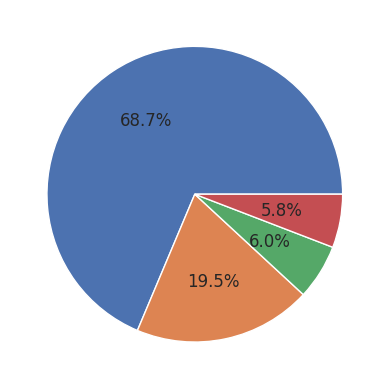

In [491]:

rare_culture = []
for culture in dict_culture.items():
  if culture[1] < 50:
    rare_culture.append(culture[0])
rare_culture

df['culture'] = df['culture'].replace(rare_culture, 'Rare')

print(df['culture'])
data = df['culture'].value_counts()

plt.pie(data, autopct='%1.1f%%')
plt.show()

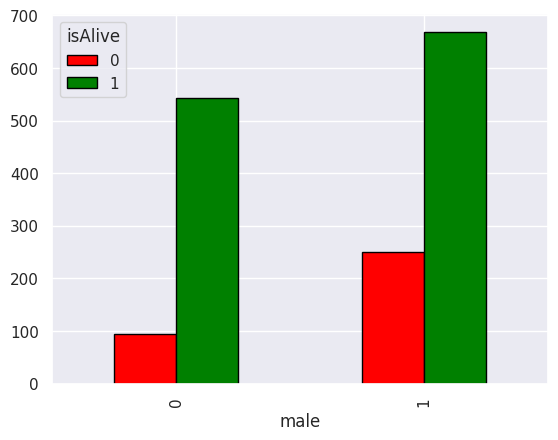

In [492]:
#другое
counts = df.groupby(['male', 'isAlive']).size().unstack()
counts.plot(kind='bar', stacked=False, color=['red', 'green'], edgecolor = 'black')
plt.show()

### Анализ даты рождения

Аналогично с возрастом заполняю -1

In [493]:
df['dateOfBirth'] = df['dateOfBirth'].fillna(-1)

### Анализ столбца house

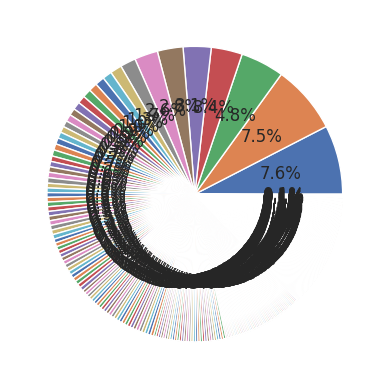

In [494]:
data = df['house'].value_counts()
plt.pie(data, autopct='%1.1f%%')
plt.show()

S.No
1                   other
2              House Frey
3             House Swyft
4             House Arryn
5          House Santagar
              ...        
1553                other
1554                other
1555       House Seaworth
1556           House Reed
1557    House Hetherspoon
Name: house, Length: 1557, dtype: object
{'other': np.int64(381), 'House Frey': np.int64(89), "Night's Watch": np.int64(88), 'House Stark': np.int64(56), 'House Targaryen': np.int64(40), 'House Lannister': np.int64(36), 'House Tyrell': np.int64(33), 'House Greyjoy': np.int64(30), 'House Osgrey': np.int64(20), 'Faith of the Seven': np.int64(15), 'House Botley': np.int64(12), 'House Hightower': np.int64(12), 'House Martell': np.int64(11), 'House Arryn': np.int64(11), 'House Florent': np.int64(10), 'House Crakehall': np.int64(10), 'House Bracken': np.int64(9), 'House Waynwood': np.int64(9), 'House Brax': np.int64(8), 'Stone Crows': np.int64(8), 'House Wylde': np.int64(8), 'House Tully': np.int64(8), 'Ho

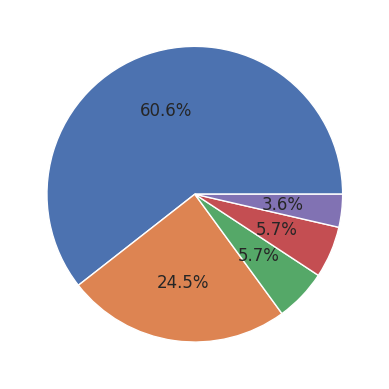

In [495]:
df['house'] = df['house'].fillna('other')
print(df['house'])

dict_house = dict(df['house'].value_counts())
print(dict_house)

rare_house = []
for house in dict_house.items():
  if house[1] < 50:
    rare_house.append(house[0])
rare_house

df['house'] = df['house'].replace(rare_house, 'Rare')

print(df['house'].unique())

data = df['house'].value_counts()
plt.pie(data, autopct='%1.1f%%')
plt.show()

### Анализ столбцов mother, father, heir, spouse, isAliveMother, isAliveFather, isAliveHeir, isAliveSpouse

In [496]:
df['mother'] = df['mother'].fillna('other')
df['father'] = df['father'].fillna('other')
df['heir'] = df['heir'].fillna('other')
df['spouse'] = df['spouse'].fillna('other')

In [497]:
median_isAliveMother = np.quantile(df['isAliveMother'].dropna().values,q=0.5)
median_isAliveFather = np.quantile(df['isAliveFather'].dropna().values,q=0.5)
median_isAliveHeir = np.quantile(df['isAliveHeir'].dropna().values,q=0.5)
median_isAliveSpouse = np.quantile(df['isAliveSpouse'].dropna().values,q=0.5)

df['isAliveMother'] = df['isAliveMother'].fillna(median_isAliveMother)
df['isAliveFather'] = df['isAliveFather'].fillna(median_isAliveFather)
df['isAliveHeir'] = df['isAliveHeir'].fillna(median_isAliveFather)
df['isAliveSpouse'] = df['isAliveSpouse'].fillna(median_isAliveSpouse)


In [498]:
df.isna().sum()

,0
name,0
title,0
male,0
culture,0
dateOfBirth,0
mother,0
father,0
heir,0
house,0
spouse,0


In [499]:
df

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,other,1,other,-1.0,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,other,other,...,1.0,0.0,0.0,1.0,0,0,-1.0,11,0.605351,0
2,Walder Frey,Rare,1,Rare,208.0,other,other,other,House Frey,Perra Royce,...,1.0,0.0,0.0,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,other,-1.0,other,other,other,Rare,other,...,1.0,0.0,0.0,1.0,0,1,-1.0,0,0.267559,1
4,Aemma Arryn,Rare,0,other,82.0,other,other,other,Rare,Viserys I Targaryen,...,1.0,0.0,0.0,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Rare,0,Rare,276.0,other,other,other,Rare,Eldon Estermont,...,1.0,0.0,0.0,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Rare,1,other,-1.0,other,other,other,other,other,...,1.0,0.0,0.0,1.0,0,1,-1.0,0,0.160535,1
1554,Masha Heddle,other,0,other,-1.0,other,other,other,other,other,...,1.0,0.0,0.0,1.0,0,0,-1.0,0,0.040134,0
1555,Matthos Seaworth,other,1,other,-1.0,other,other,other,Rare,other,...,1.0,0.0,0.0,1.0,0,0,-1.0,0,0.076923,0


**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [500]:
df['isPopular'] = df['popularity']
df.loc[df['isPopular'] <= 0.5, 'isPopular'] = 0
df.loc[df['isPopular'] > 0.5, 'isPopular'] = 1
print(df['isPopular'].value_counts())

df['boolDeadRelations'] = df['numDeadRelations']
df.loc[df['boolDeadRelations'] > 0, 'boolDeadRelations'] = 1
print(df['boolDeadRelations'].value_counts())

isPopular
0.0    1530
1.0      27
Name: count, dtype: int64
boolDeadRelations
0    1488
1      69
Name: count, dtype: int64


In [501]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

replacement_dict = {}
for main_name, variants in cult.items():
    for variant in variants:
        replacement_dict[variant] = main_name

def replace_culture(value):
    value_str = str(value).lower().strip()
    if value_str in replacement_dict:
        return replacement_dict[value_str]
    else:
        return value

df['culture'] = df['culture'].apply(replace_culture)
df['culture'].value_counts()

,count
culture,
other,1069
Rare,303
Northmen,94
Ironborn,91


In [502]:
df

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,other,1,other,-1.0,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,other,other,...,0.0,1.0,0,0,-1.0,11,0.605351,0,1.0,1
2,Walder Frey,Rare,1,Rare,208.0,other,other,other,House Frey,Perra Royce,...,0.0,1.0,1,1,97.0,1,0.896321,1,1.0,1
3,Addison Hill,Ser,1,other,-1.0,other,other,other,Rare,other,...,0.0,1.0,0,1,-1.0,0,0.267559,1,0.0,0
4,Aemma Arryn,Rare,0,other,82.0,other,other,other,Rare,Viserys I Targaryen,...,0.0,0.0,1,1,23.0,0,0.183946,0,0.0,0
5,Sylva Santagar,Rare,0,Rare,276.0,other,other,other,Rare,Eldon Estermont,...,0.0,1.0,1,1,29.0,0,0.043478,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Rare,1,other,-1.0,other,other,other,other,other,...,0.0,1.0,0,1,-1.0,0,0.160535,1,0.0,0
1554,Masha Heddle,other,0,other,-1.0,other,other,other,other,other,...,0.0,1.0,0,0,-1.0,0,0.040134,0,0.0,0
1555,Matthos Seaworth,other,1,other,-1.0,other,other,other,Rare,other,...,0.0,1.0,0,0,-1.0,0,0.076923,0,0.0,0


In [503]:
#добавление признака isAlive
df['isAlive_305'] = np.nan

# Если dateOfBirth + age == 305 → жив (1)
alive_mask = (df['dateOfBirth'] + df['age'] == 305)
df.loc[alive_mask, 'isAlive_305'] = 1

# Если dateOfBirth + age < 305 → умер (0)
dead_mask = (df['dateOfBirth'] + df['age'] < 305)
df.loc[dead_mask, 'isAlive_305'] = 0

nan_mask = (df['dateOfBirth'] + df['age'] < 0)
df.loc[nan_mask, 'isAlive_305'] = -1
df

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations,isAlive_305
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,other,1,other,-1.0,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,other,other,...,1.0,0,0,-1.0,11,0.605351,0,1.0,1,-1.0
2,Walder Frey,Rare,1,Rare,208.0,other,other,other,House Frey,Perra Royce,...,1.0,1,1,97.0,1,0.896321,1,1.0,1,1.0
3,Addison Hill,Ser,1,other,-1.0,other,other,other,Rare,other,...,1.0,0,1,-1.0,0,0.267559,1,0.0,0,-1.0
4,Aemma Arryn,Rare,0,other,82.0,other,other,other,Rare,Viserys I Targaryen,...,0.0,1,1,23.0,0,0.183946,0,0.0,0,0.0
5,Sylva Santagar,Rare,0,Rare,276.0,other,other,other,Rare,Eldon Estermont,...,1.0,1,1,29.0,0,0.043478,1,0.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Rare,1,other,-1.0,other,other,other,other,other,...,1.0,0,1,-1.0,0,0.160535,1,0.0,0,-1.0
1554,Masha Heddle,other,0,other,-1.0,other,other,other,other,other,...,1.0,0,0,-1.0,0,0.040134,0,0.0,0,-1.0
1555,Matthos Seaworth,other,1,other,-1.0,other,other,other,Rare,other,...,1.0,0,0,-1.0,0,0.076923,0,0.0,0,-1.0


**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [504]:
# удаление признаков, в которых было изначально много пропусков - column_del
# удаление признаков name , numDeadRelations, popularity
df.drop(columns = column_del, inplace = True)
df.drop(columns= ['name', 'numDeadRelations', 'popularity', 'dateOfBirth'], inplace = True)
df

,title,male,culture,house,book1,book2,book3,book4,book5,isMarried,isNoble,age,isAlive,isPopular,boolDeadRelations,isAlive_305
S.No,,,,,,,,,,,,,,,,
1,other,1,other,other,0,0,0,0,0,0,0,-1.0,0,1.0,1,-1.0
2,Rare,1,Rare,House Frey,1,1,1,1,1,1,1,97.0,1,1.0,1,1.0
3,Ser,1,other,Rare,0,0,0,1,0,0,1,-1.0,1,0.0,0,-1.0
4,Rare,0,other,Rare,0,0,0,0,0,1,1,23.0,0,0.0,0,0.0
5,Rare,0,Rare,Rare,0,0,0,1,0,1,1,29.0,1,0.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Rare,1,other,other,1,0,1,1,0,0,1,-1.0,1,0.0,0,-1.0
1554,other,0,other,other,1,1,0,0,0,0,0,-1.0,0,0.0,0,-1.0
1555,other,1,other,Rare,0,1,1,1,1,0,0,-1.0,0,0.0,0,-1.0


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

In [505]:
df['isAlive'].info()

<class 'pandas.core.series.Series'>
Index: 1557 entries, 1 to 1557
Series name: isAlive
Non-Null Count  Dtype
--------------  -----
1557 non-null   int64
dtypes: int64(1)
memory usage: 56.6 KB


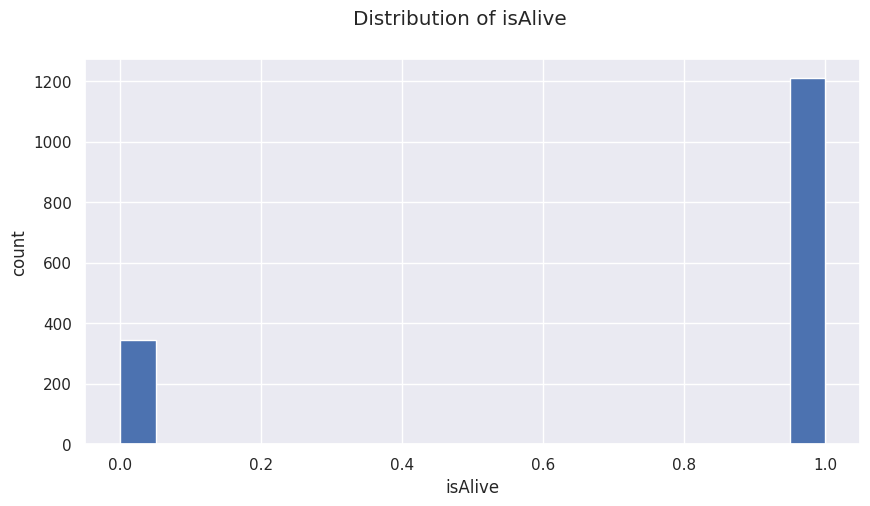

In [506]:
plt.figure(figsize = (10, 5))

df['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('isAlive')

plt.suptitle('Distribution of isAlive')
plt.show()

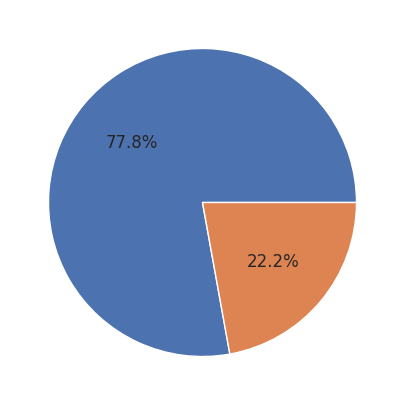

In [507]:
plt.figure(figsize = (10, 5))

data = df['isAlive'].value_counts()
plt.pie(data, autopct='%1.1f%%')
plt.show()

данные считаю сбалансированными

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [508]:
categorical_columns = ['title', 'culture', 'house']
categorical_features = df[categorical_columns]
categorical_features.columns

Index(['title', 'culture', 'house'], dtype='object')

In [509]:
unprocessed_cat_features = categorical_features.select_dtypes(include=[object]).columns.tolist()
unprocessed_cat_features

['title', 'culture', 'house']

### One-hot encoding

In [510]:
from sklearn.preprocessing import OneHotEncoder

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=df.index
                          )

In [511]:
one_hot_df

,title_Rare,title_Ser,title_other,culture_Ironborn,culture_Northmen,culture_Rare,culture_other,house_House Frey,house_House Stark,house_Night's Watch,house_Rare,house_other
S.No,,,,,,,,,,,,
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1554,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1555,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [513]:
# Concatenate the one-hot encoded dataframe with the original dataframe
df_encoded = pd.concat([df, one_hot_df], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(unprocessed_cat_features, axis=1)

# Display the resulting dataframe
df_encoded

,male,book1,book2,book3,book4,book5,isMarried,isNoble,age,isAlive,...,title_other,culture_Ironborn,culture_Northmen,culture_Rare,culture_other,house_House Frey,house_House Stark,house_Night's Watch,house_Rare,house_other
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1,1,1,1,1,1,97.0,1,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0,0,0,1,0,0,1,-1.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0,0,0,0,1,1,23.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,0,0,0,0,1,0,1,1,29.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,-1.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1554,0,1,1,0,0,0,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1555,1,0,1,1,1,1,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Анализ числовых признаков

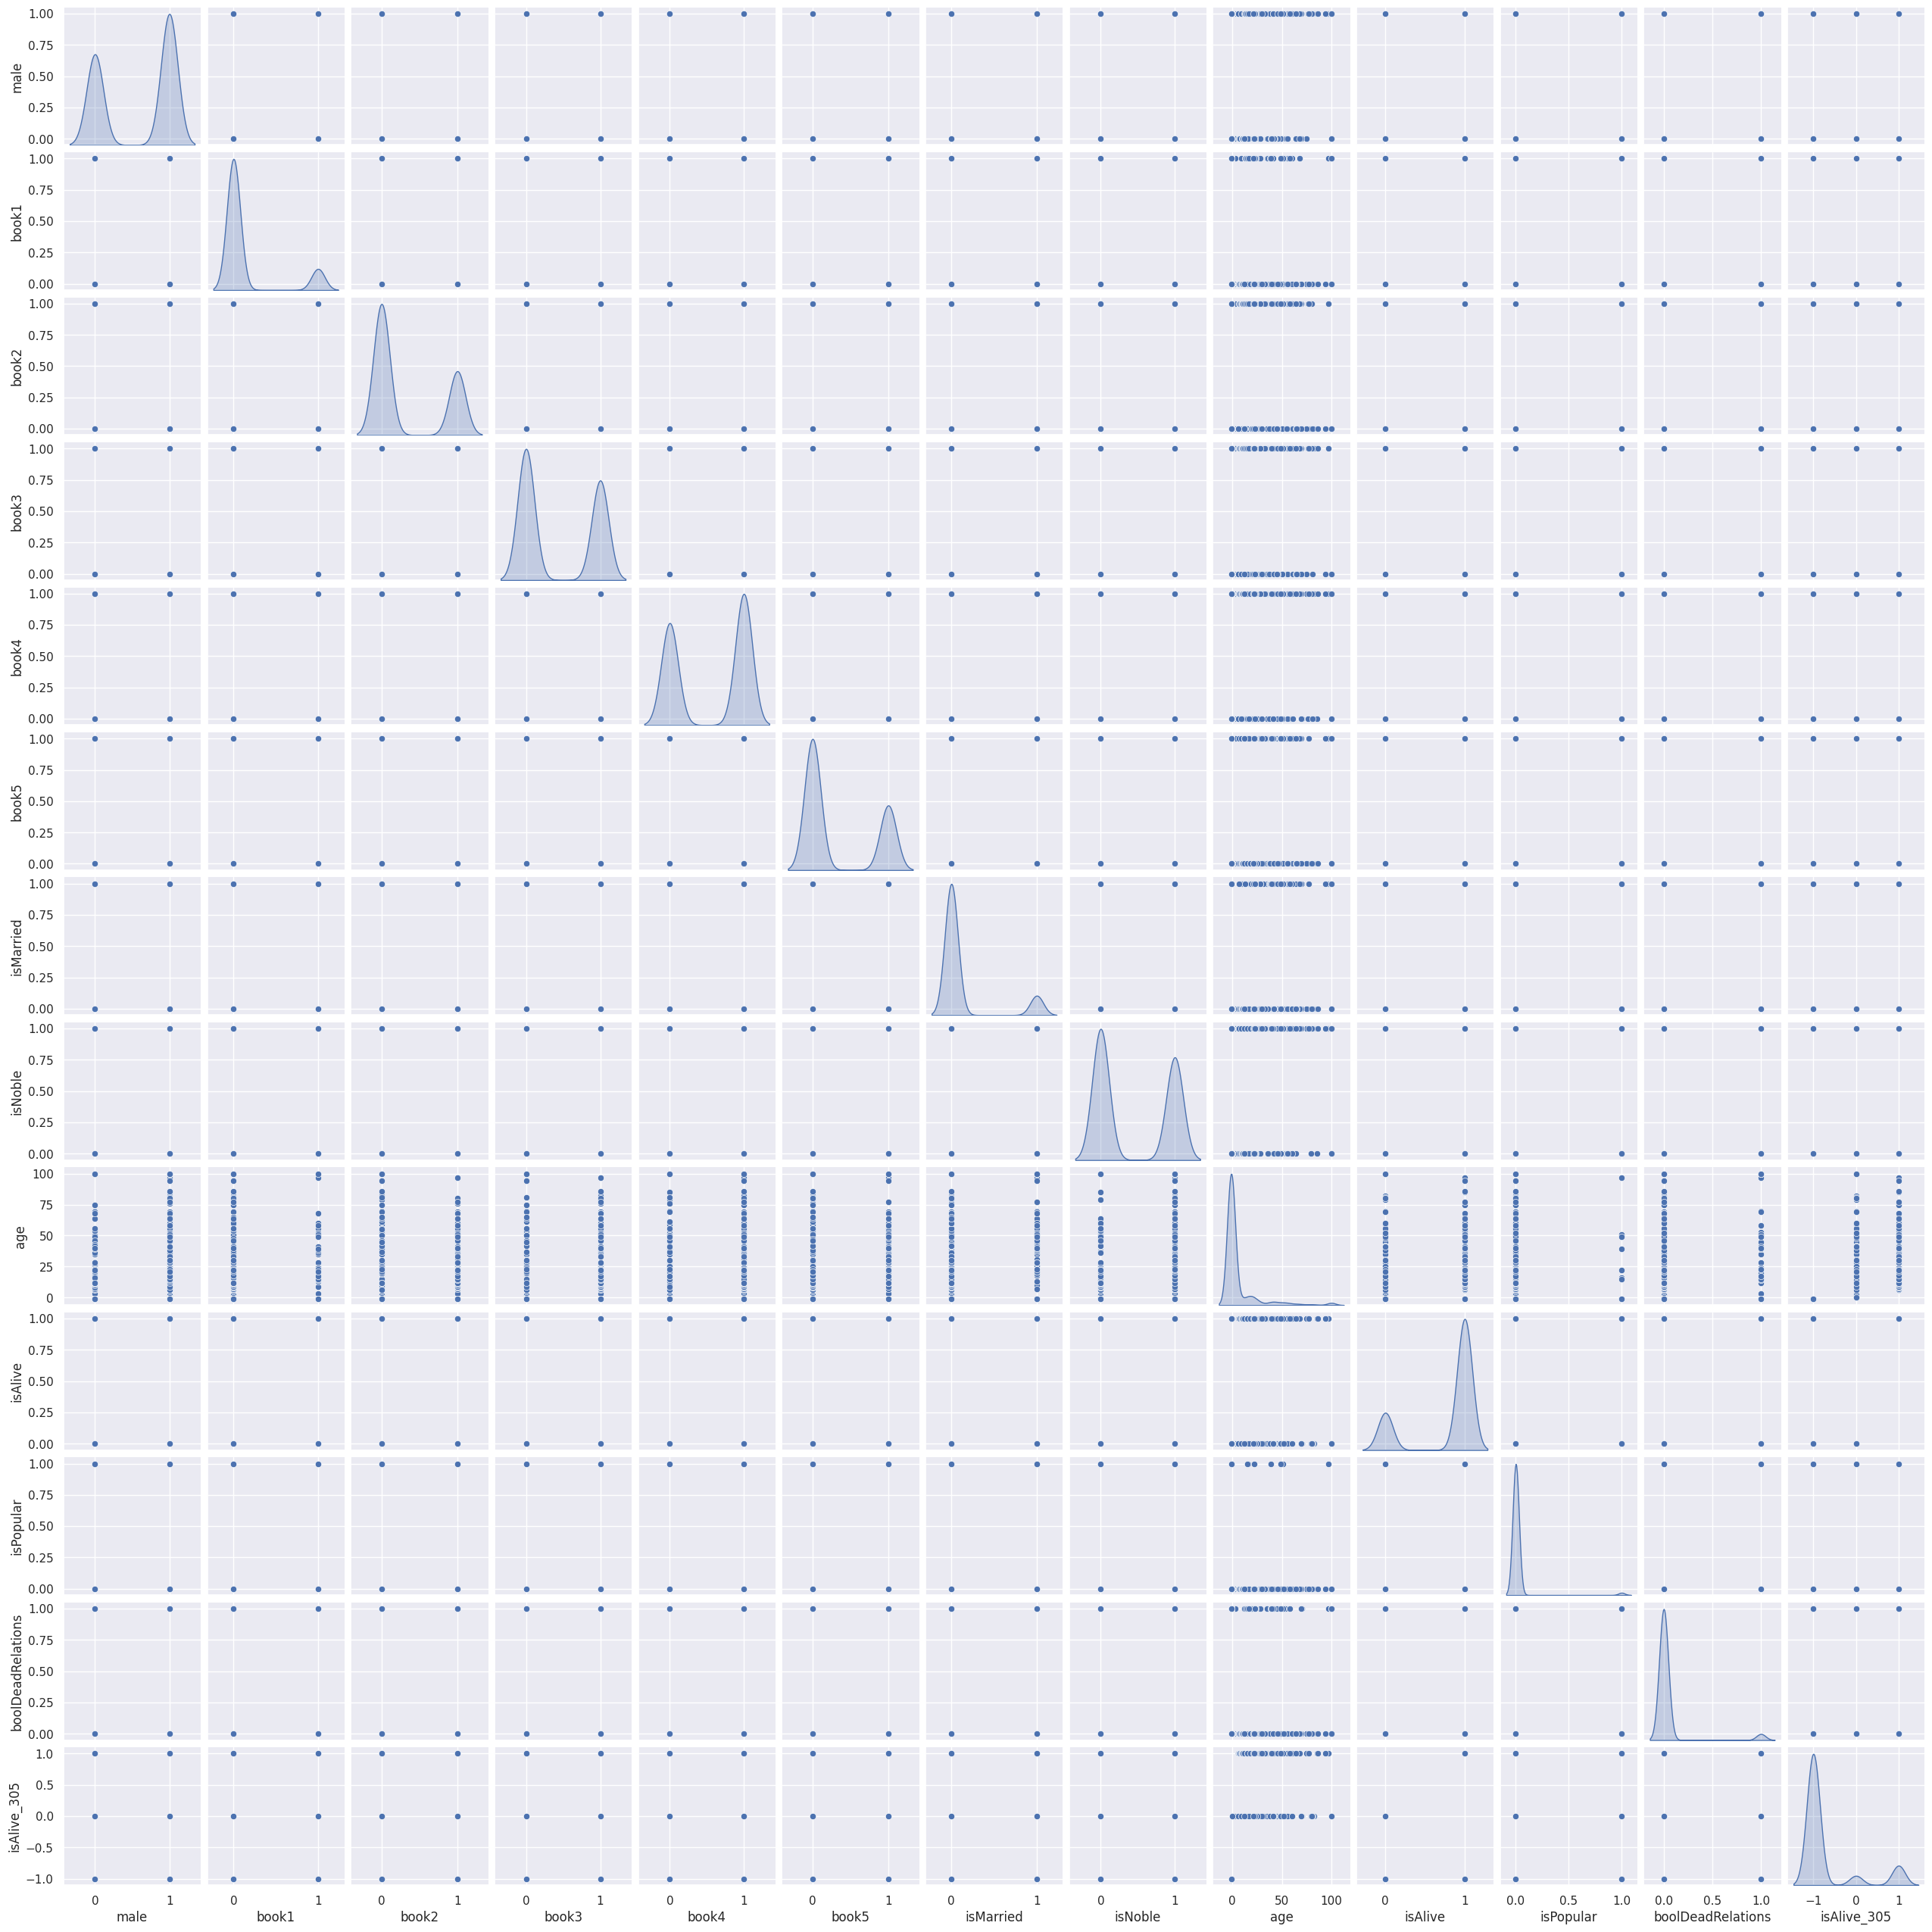

In [514]:
sns.set()
sns.pairplot(df, height = 2 ,kind ='scatter',diag_kind='kde') # взаимные графики на куче признаков
plt.show()

### Матрица корреляции

In [518]:
df_encoded

,male,book1,book2,book3,book4,book5,isMarried,isNoble,age,isAlive,...,title_other,culture_Ironborn,culture_Northmen,culture_Rare,culture_other,house_House Frey,house_House Stark,house_Night's Watch,house_Rare,house_other
S.No,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,1,1,1,1,1,1,1,97.0,1,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0,0,0,1,0,0,1,-1.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0,0,0,0,1,1,23.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,0,0,0,0,1,0,1,1,29.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,1,1,0,1,1,0,0,1,-1.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1554,0,1,1,0,0,0,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1555,1,0,1,1,1,1,0,0,-1.0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


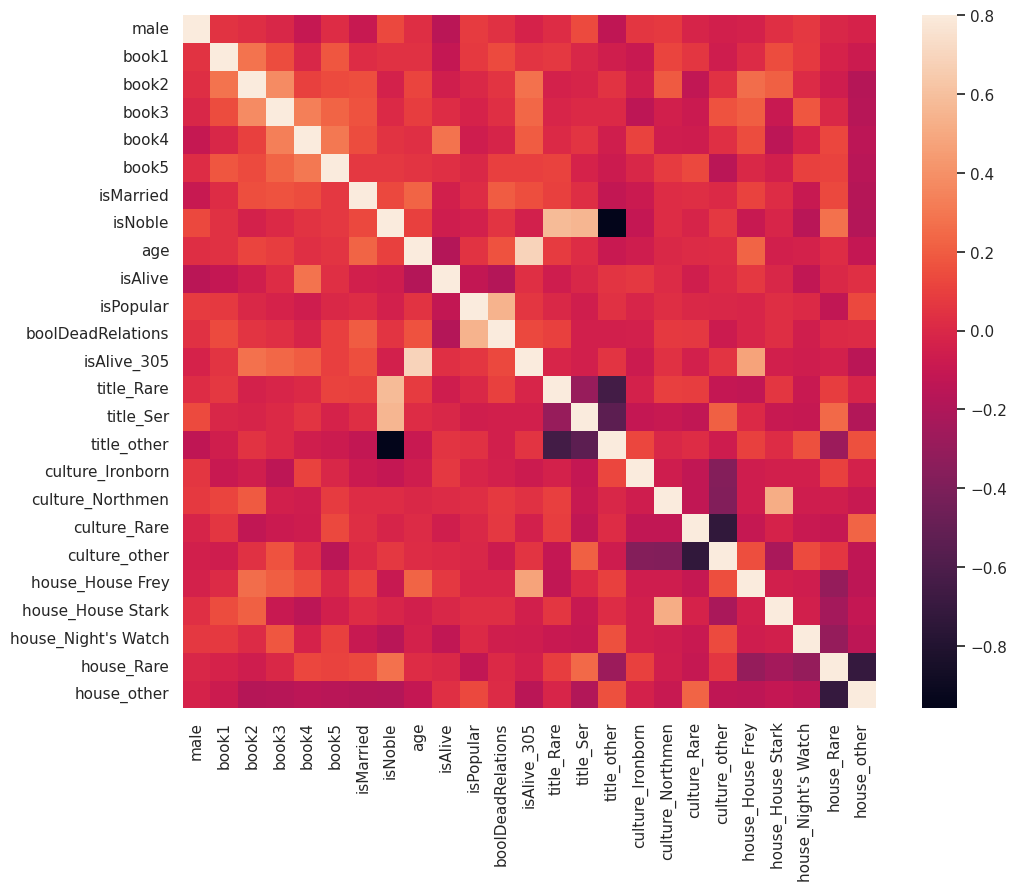

In [519]:
corrmat = df_encoded.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

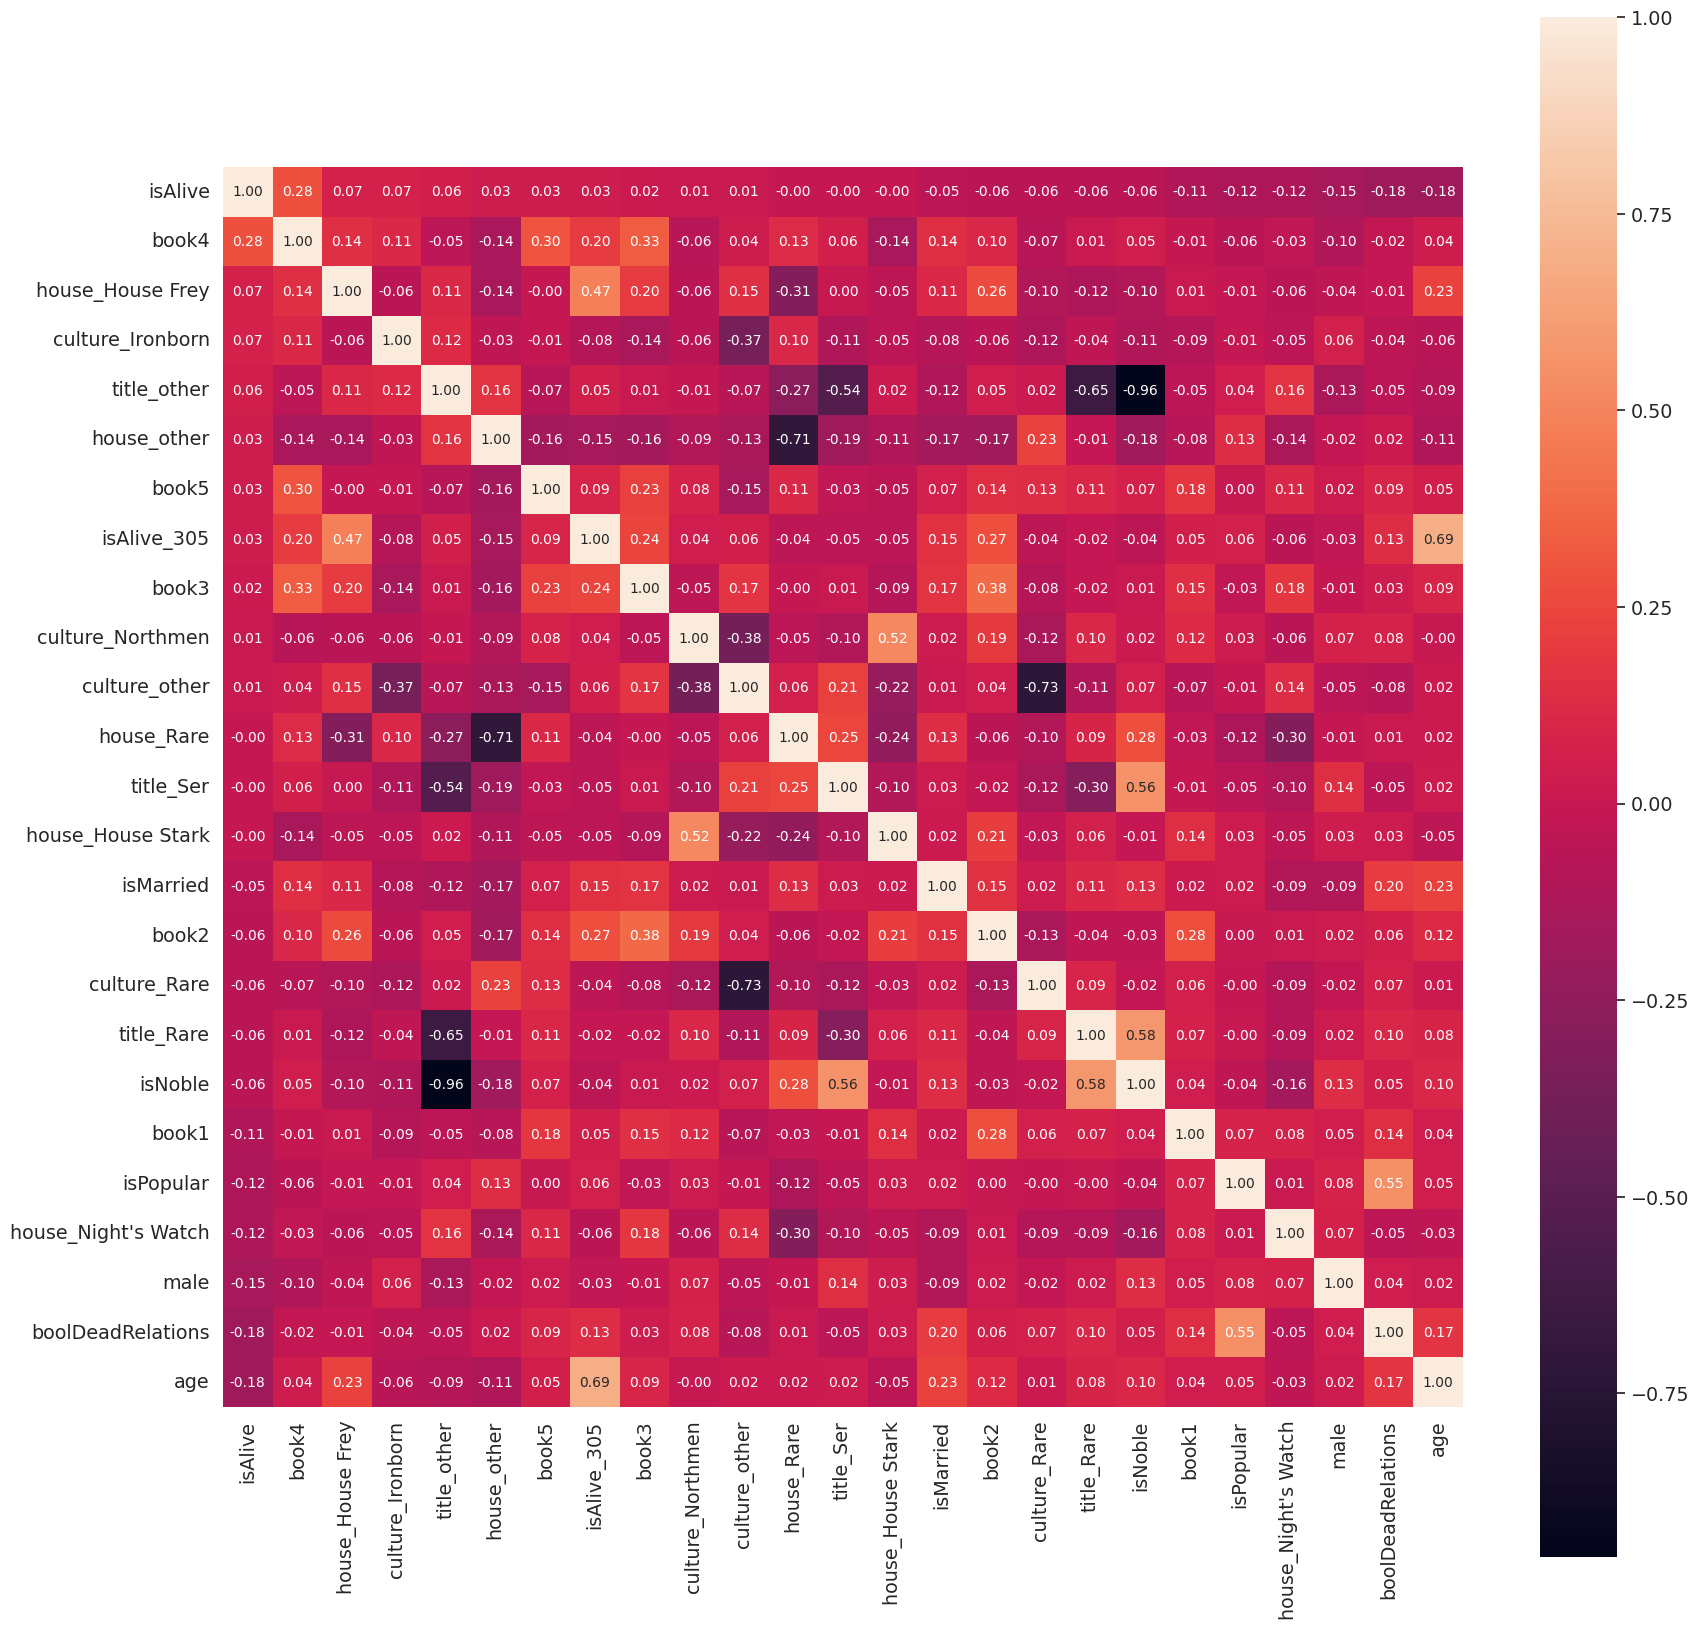

In [524]:
# correlation matrix
k = 25 # number of variables for heatmap
plt.figure(figsize=(20, 20))
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(df_encoded[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

Нарисуем круговую диаграмму isAlive в зависимости от пола.

In [525]:
df[df['male'] == 1]['isAlive'].value_counts()

,count
isAlive,
1,669
0,251


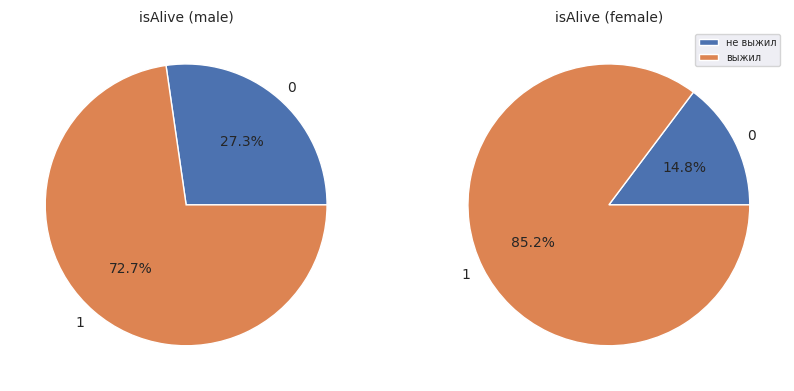

In [530]:
# female - 0, male - 1
data_1 = df[df['male']== 1]['isAlive'].value_counts().sort_values()
data_2 = df[df['male']== 0]['isAlive'].value_counts().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (male)', fontsize=10)
ax2.set_title('isAlive (female)', fontsize=10)

plt.legend(['не выжил', 'выжил'], fontsize=7)

plt.show()

Можно заметить, что женщины в большей степени выжили.

isAlive от age

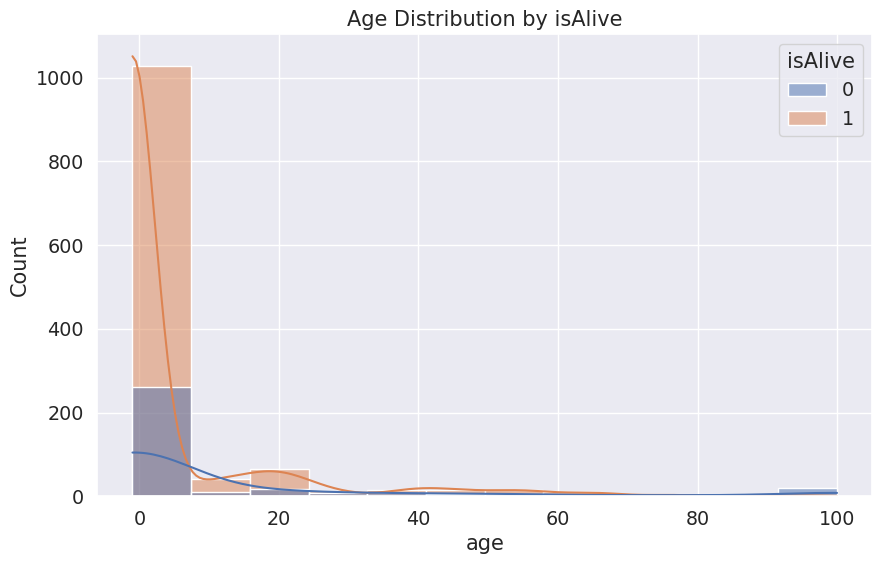

In [531]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, hue='isAlive')
plt.title('Age Distribution by isAlive')
plt.show()

In [ ]:
# Готовим данные для графика
data1 = df['Fare'][df['Survived'] == 0]
data2 = df['Fare'][df['Survived'] == 1]
data1.head()

# Строим боксплот

plt.figure(figsize=(10, 7))

plt.boxplot([data1, data2])

plt.title('Влияние стоимости билета на выживаемость')
plt.xlabel('Выжили')
plt.ylabel('Стоимость билета')
plt.xticks([1, 2], ['Нет', 'Да'])

plt.show()

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [532]:
X = df_encoded.drop(columns=['isAlive']).values
y = df_encoded['isAlive'].values

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [533]:
from sklearn.model_selection import train_test_split

In [534]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from ... import AdaBoostClassifier, RandomForestClassifier
from ... import GaussianProcessClassifier
from ... import GaussianNB
from ... import KNeighborsClassifier
from ... import SVC
from ... import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели


# Шаг 2. обучение модели


# Шаг 3. Предсказание на тестовых данных


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [ ]:
# Шаг 3. Предсказание на тестовых данных


# Шаг 4. Оценка предсказания по метрике accuracy

print("Accuracy : %.4f" % accuracy)

Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 9.42MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)